# Marketing Campaign Analysis

## Objective
The goal of this analysis is to explore customer data and understand the factors influencing purchasing behavior and campaign success.

## Dataset Overview
The dataset contains customer demographics, spending patterns, and campaign responses aligned with the 4 Ps of marketing:
- People (Demographics)
- Product (Spending)
- Place (Purchase channels)
- Promotion (Campaign responses)

In [375]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 📂 Loading & Initial Inspection of the Data

We load the dataset and perform an initial inspection to understand the structure, data types, and presence of missing values. Key columns of immediate interest are:
- `Income` — stored as a string with `$` signs and commas, requiring cleaning.
- `Dt_Customer` — a date column stored as a string, requiring conversion to `datetime`.
- `Education` and `Marital_Status` — categorical columns that may contain inconsistent entries.

In [376]:
data=pd.read_csv("/Users/air/Downloads/marketing_data.csv")
data.columns=data.columns.str.strip()
pd.set_option('display.max_columns',None)
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP


In [377]:
print("Shape of the data======>",data.shape,"\n")
print("\n =============Data Info=============\n",data.info(),"\n")
print("\n=============Missing Values============\n",data.isna().sum(),"\n")
print("Duplicates=========>",data.duplicated().sum())

Shape of the data======> (2240, 28) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases

### 🔍 Observations — Initial Data Inspection

- The dataset contains **2,240 rows and 28 columns**, covering customer demographics, spending behaviour, purchase channels, and campaign responses.
- **`Income`** is read as an `object` (string) due to the `$` and comma formatting — this must be converted to `float64` before any numerical analysis.
- **`Dt_Customer`** is stored as a string — needs conversion to `datetime` to enable time-based analysis.
- There are **24 missing values** in `Income` (~1.1% of the dataset). These will be imputed using group-level medians.
- **No duplicate rows** were found, so no deduplication is necessary.
- The `ID` column is a unique identifier with no analytical value and will be dropped.

---

In [378]:
# Drop ID — not useful for analysis
data = data.drop('ID', axis=1)

## Data Type Correction

Before handling missing values or performing analysis, we need to:
1. **Convert `Dt_Customer`** from string to `datetime`.
2. **Clean and convert `Income`** by removing the `$` sign and commas, then casting to `float64`.

In [379]:
data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,SP
1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,CA
2,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,US
3,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,AUS
4,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,SP


In [380]:
# Fix Dt_Customer to datetime
data['Dt_Customer']=pd.to_datetime(data['Dt_Customer'])

# Fix Income: remove $, commas, whitespace → convert to float
data['Income'] = pd.to_numeric(
    data['Income']
        .str.replace(r'[,$%]', '', regex=True)  
        .str.strip(),                          
    errors='coerce'
)
print('Income dtype:', data['Income'].dtype)
print('Dt_Customer dtype:', data['Dt_Customer'].dtype)
print('Missing Income values:', data['Income'].isna().sum())

Income dtype: float64
Dt_Customer dtype: datetime64[ns]
Missing Income values: 24


### Observations — Data Type Correction

- **`Income`** has been successfully converted to `float64`. The cleaning step removed currency symbols, resulting in **24 NaN values** that reflect genuinely missing data (not parsing errors).
- **`Dt_Customer`** is now correctly typed as `datetime64[ns]`, enabling future date-based feature engineering.

---

## Data Cleaning — Categorical Variables

Before imputing missing income values, we must standardize the categorical grouping columns (`Education` and `Marital_Status`), as inconsistent categories would skew group-level medians.

### Education
The `'2n Cycle'` entry (a European term for a 2-year post-graduate cycle) is educationally equivalent to `'Graduation'` and is consolidated accordingly.

### Marital Status
Several non-standard entries exist:
- `'YOLO'`, `'Alone'`, `'Absurd'` → consolidated into `'Single'` (these indicate living alone / non-partnered status).
- `'Together'` → merged into `'Married'` (cohabiting partners have similar financial profiles to married couples).
- `'Divorced'` and `'Widow'` are retained separately as they have distinct socioeconomic profiles.

In [381]:
print(data['Education'].unique())

['Graduation' 'PhD' '2n Cycle' 'Master' 'Basic']


In [382]:
data['Education']=data['Education'].replace({'2n Cycle':'Graduation'})
print(data['Education'].unique())

['Graduation' 'PhD' 'Master' 'Basic']


In [383]:
print(data['Marital_Status'].unique())

['Divorced' 'Single' 'Married' 'Together' 'Widow' 'YOLO' 'Alone' 'Absurd']


In [384]:
data['Marital_Status'] = data['Marital_Status'].replace({
    'YOLO'  : 'Single',
    'Alone' : 'Single',
    'Absurd': 'Single',
    'Together': 'Married'
})
# Note: Divorced and Widow are kept separate — they have different income profiles
print('Marital Status categories:', data['Marital_Status'].unique())

Marital Status categories: ['Divorced' 'Single' 'Married' 'Widow']


### Observations — Categorical Cleaning

- **Education** now has 4 clean categories: `Basic`, `Graduation`, `Master`, `PhD`. The `2n Cycle` label (present in European academic contexts) was correctly mapped to `Graduation`.
- **Marital Status** is reduced from 8 noisy categories to 4 meaningful ones: `Single`, `Married`, `Divorced`, `Widow`. Ambiguous or absurd entries (`YOLO`, `Alone`, `Absurd`) were logically resolved.
- These cleaned categories will now produce more reliable group medians for income imputation.

---

## Missing Value Imputation — Income

**Strategy:** Fill missing `Income` values with the **median income** of customers sharing the same `Education` and `Marital_Status` group.

**Rationale:**
- Education level strongly correlates with earning potential.
- Marital status influences household income (e.g., dual-income married households vs. single-income households).
- **Median** is used instead of mean because income distributions are typically right-skewed; the median is more robust to outliers.

In [385]:
data['Income']=data['Income'].fillna(
    data.groupby(['Education','Marital_Status'])['Income'].transform('median'))
print("Missing values filled====>",data['Income'].isna().sum())

Missing values filled====> 0


### 🔍 Observations — Missing Value Imputation

- All **24 missing `Income` values** have been successfully filled using group-level median imputation.
- This approach is more informative than global mean/median imputation, as it preserves the income structure within each demographic subgroup.
- No records were lost, maintaining the full dataset of **2,240 rows**.

---

In [386]:
data.columns


Index(['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country'],
      dtype='object')

## Feature Engineering

In [387]:
#total childrens at home
data['Total_Children']=data['Kidhome']+data['Teenhome']

In [388]:
# Customer age (based on current year)
from datetime import datetime
current_year=datetime.now().year
data['Age']=current_year-data['Year_Birth']

In [389]:
#total spendings across all product categories
spending_cols=['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']
data['Total_spendings']=data[spending_cols].sum(axis=1)

In [390]:
purchase_cols=['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
data['Total_Purchases']=data[purchase_cols].sum(axis=1)

In [391]:
print('\n New features added: Total_Children, Age, Total_Spending, Total_Purchases\n')
data[['Total_Children', 'Age', 'Total_spendings', 'Total_Purchases']].describe()


 New features added: Total_Children, Age, Total_Spending, Total_Purchases



,Total_Children,Age,Total_spendings,Total_Purchases
count,2240.000000,2240.000000,2240.000000,2240.000000
mean,0.950446,57.194196,605.798214,12.537054
std,0.751803,11.984069,602.249288,7.205741
min,0.000000,30.000000,5.000000,0.000000
25%,0.000000,49.000000,68.750000,6.000000
50%,1.000000,56.000000,396.000000,12.000000
75%,1.000000,67.000000,1045.500000,18.000000
max,3.000000,133.000000,2525.000000,32.000000


In [392]:
data.shape

(2240, 31)

### 🔍 Observations — Feature Engineering

- **`Total_Children`**: Ranges from 0–3, with a mean of ~0.95, indicating that most customers have 0 or 1 child at home.
- **`Age`**: Ranges from 30 to **133 years** — the maximum of 133 is clearly an outlier (data entry error) and will require outlier treatment. The mean age is ~57 years.
- **`Total_spendings`**: Highly variable — minimum of \$5 and maximum of \$2,525 with a mean of ~\$606. The large standard deviation (\$602) signals right-skewed distribution with potential outliers.
- **`Total_Purchases`**: Ranges from 0–32, with a mean of ~12.5 transactions per customer.

---

## 📊 Exploratory Data Analysis — Boxplots & Histograms

We generate:
- **Boxplots** to identify the spread of distributions and detect outliers.
- **Histograms with KDE curves** to understand the shape of each distribution.

Variables of special interest for outlier detection include `Age`, `Income`, and `Total_spendings`.

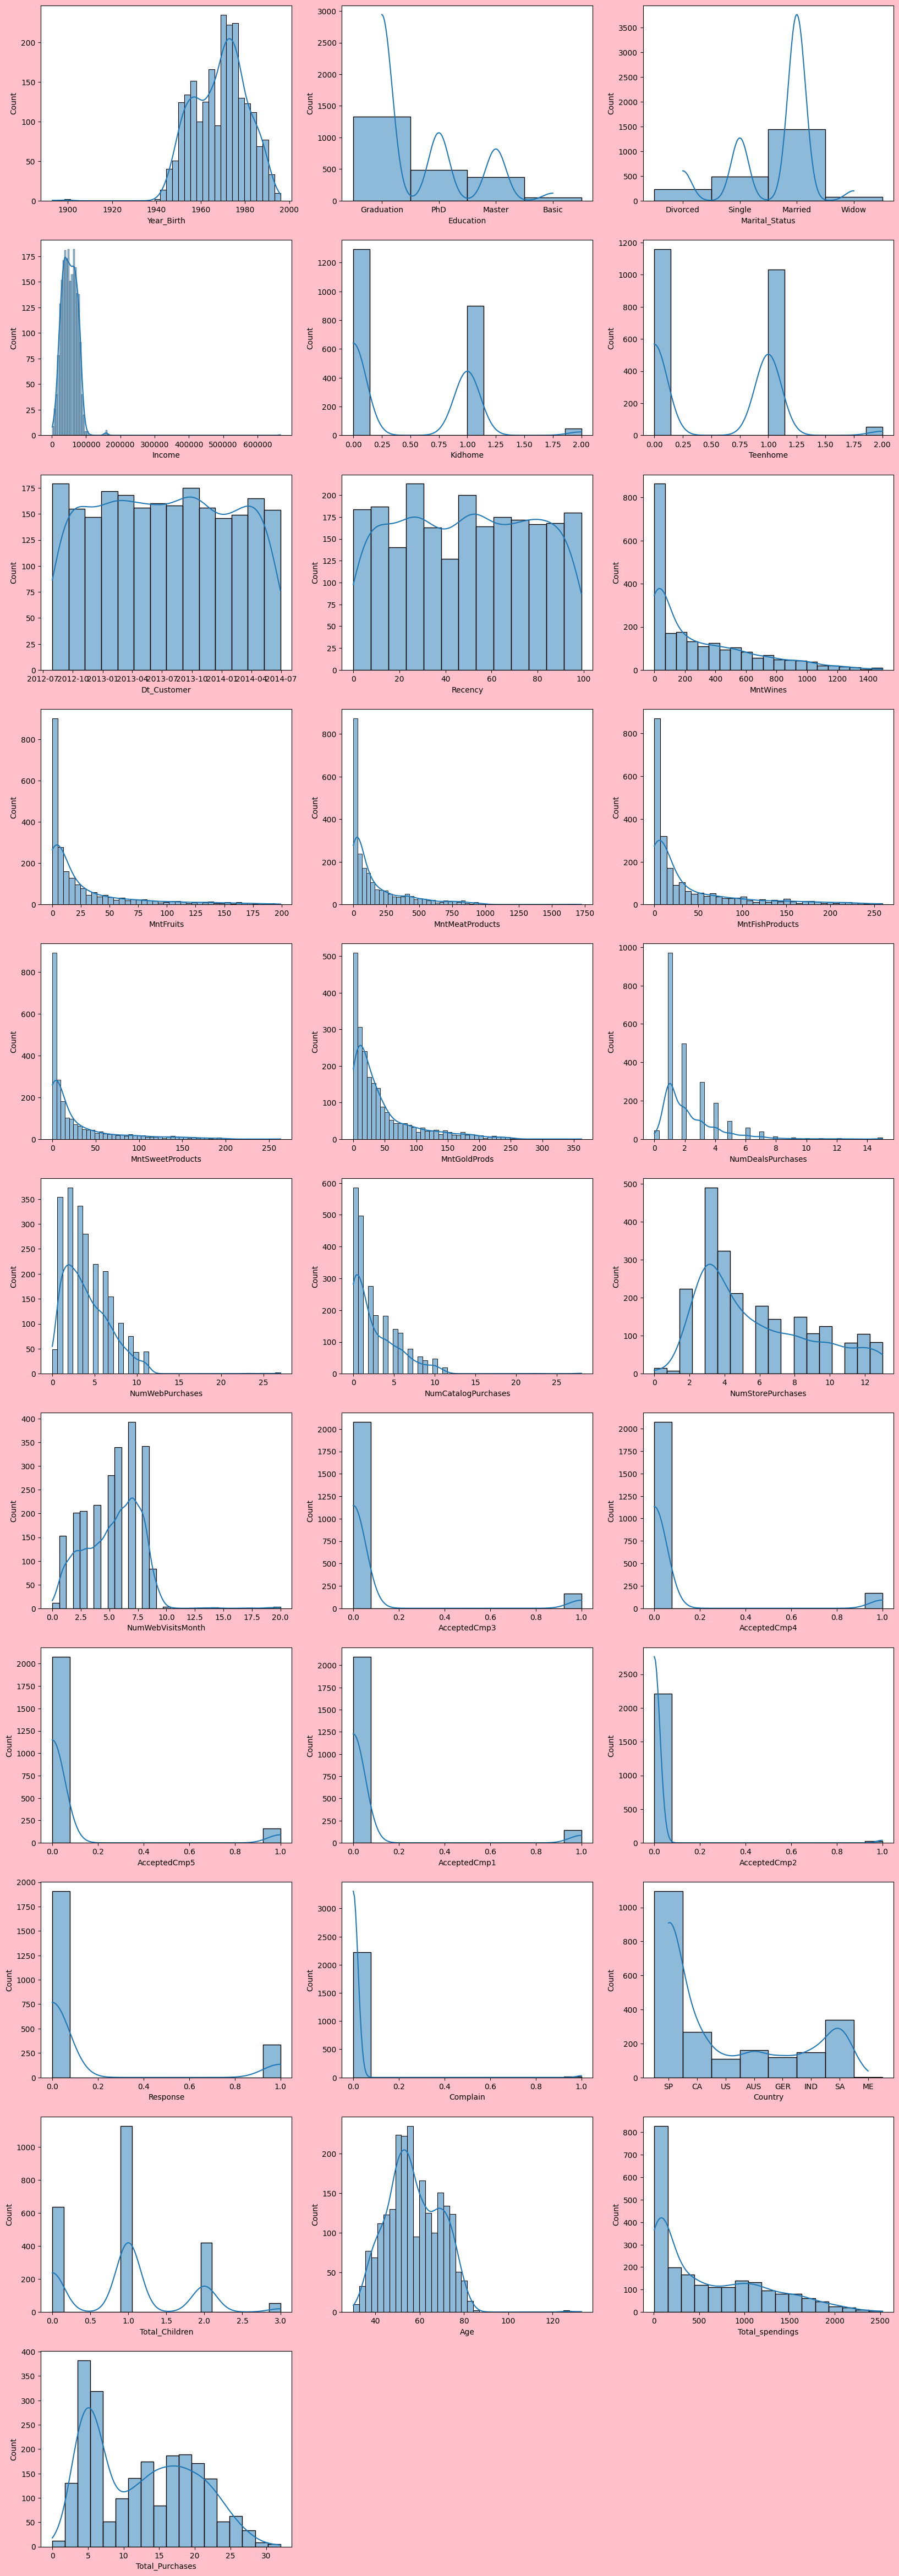

In [393]:
plt.figure(figsize=(20,60),facecolor='pink')
plot_number=1
for columns in data:
    if plot_number<=31:
        ax=plt.subplot(11,3,plot_number)
        sns.histplot(data[columns],kde=True)
        plt.xlabel(columns,fontsize=10)
        plot_number+=1
plt.show()

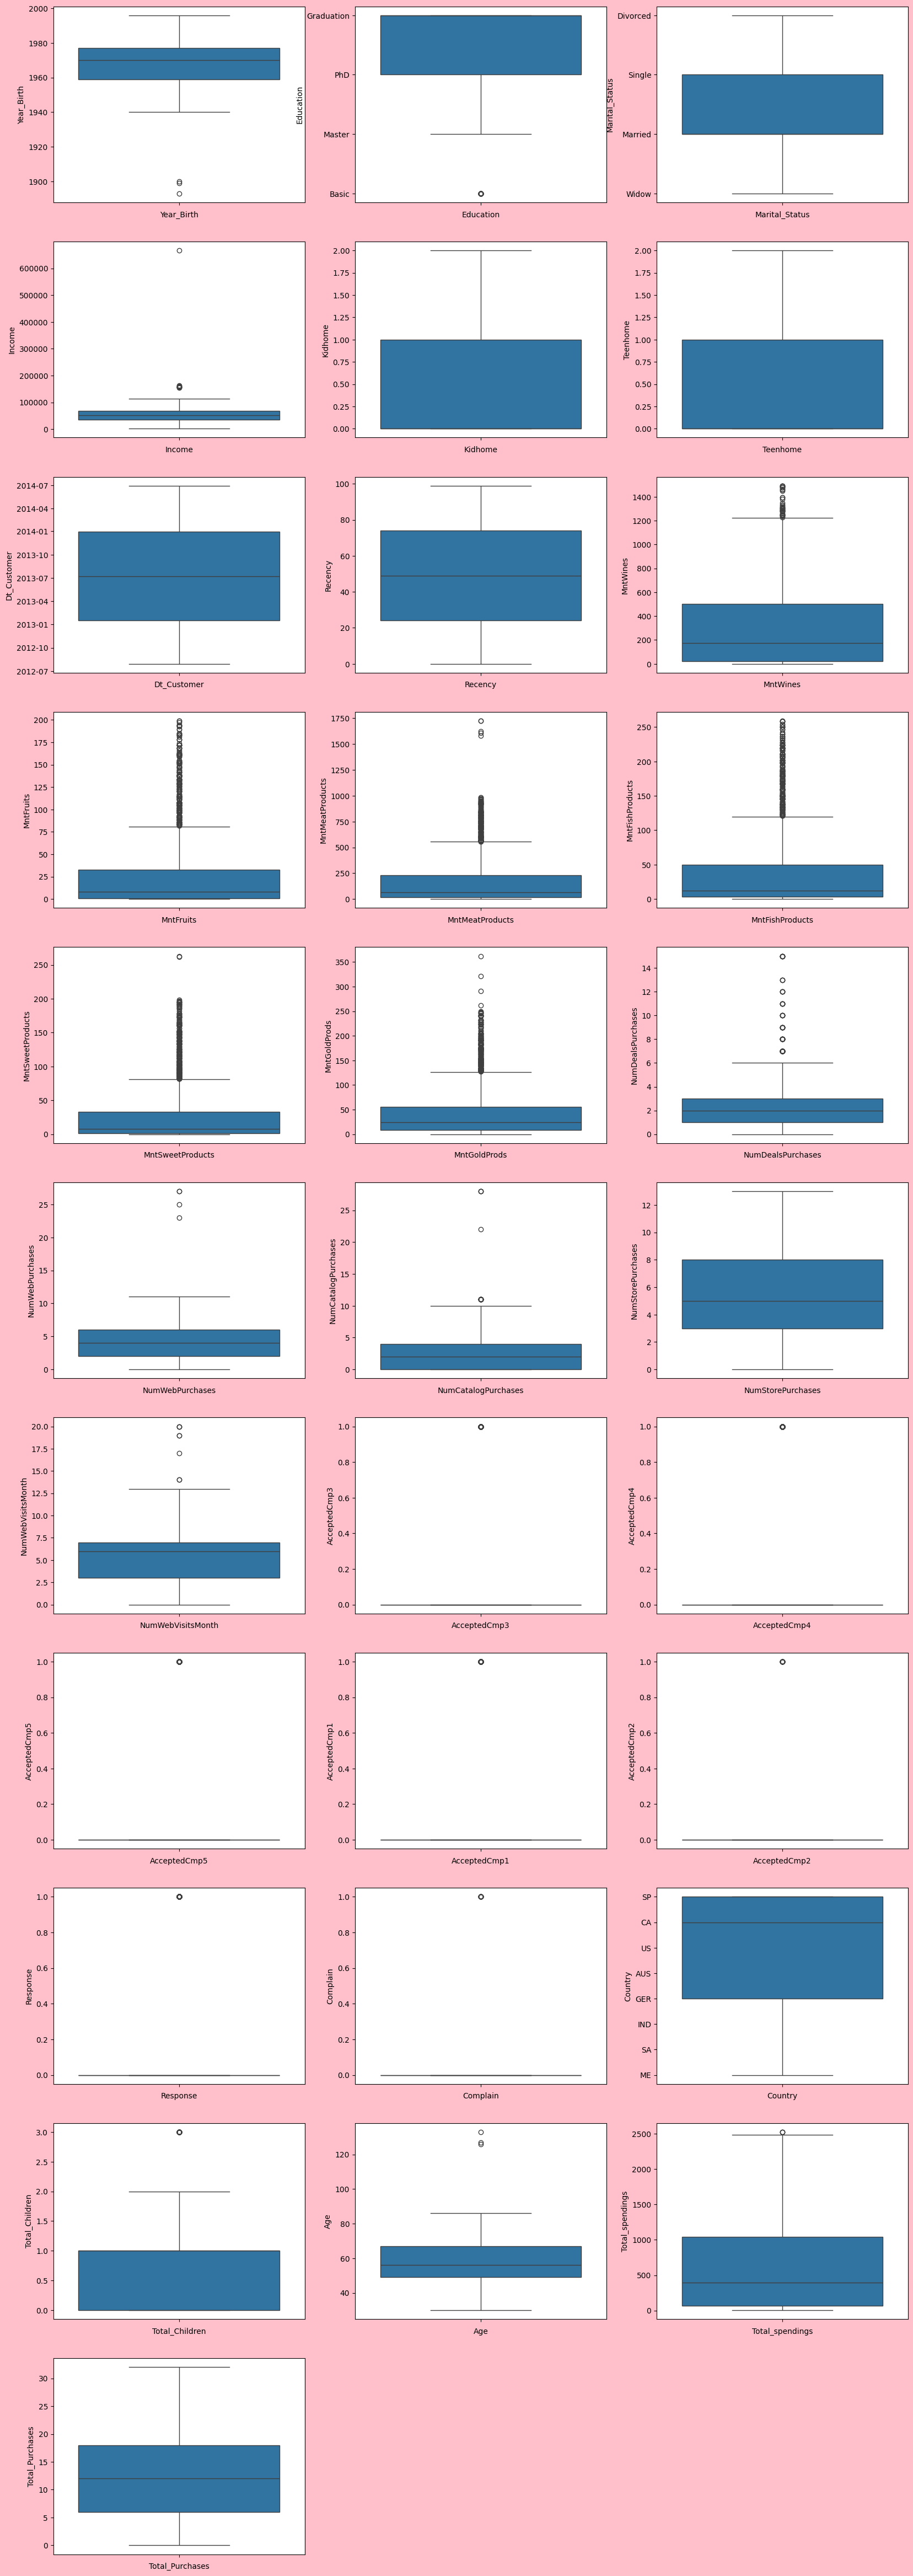

In [394]:
plt.figure(figsize=(20,60),facecolor='pink')
plot_number=1
for columns in data:
    if plot_number<=31:
        ax=plt.subplot(11,3,plot_number)
        sns.boxplot(data[columns])
        plt.xlabel(columns,fontsize=10)
        plot_number+=1
plt.show()

### 🔍 Observations — Distributions & Outliers

**From Boxplots:**
- **`Age`** shows extreme outliers — customers with birth years suggesting ages above 100 (e.g., born in 1893, 1900). These are almost certainly data entry errors.
- **`Income`** has a significant upper outlier around \$666,666 —
- an implausibly high value that is several standard deviations above the mean (~\$52,000).
- **`MntWines`** and **`MntMeatProducts`** display strong right-skew with several high-value outliers.
- Channel-usage variables (`NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`) are relatively well-bounded.

**From Histograms:**
- **`Income`** follows an approximately normal distribution (after excluding the extreme outlier), centered around \$50,000–\$55,000.
- **`Total_spendings`** is heavily right-skewed — a large proportion of customers are low spenders, while a small segment drives disproportionately high spending.
- **`Age`** is roughly bell-shaped with most customers between 40–70 years, but with the anomalous tail extending to 133.
- **Campaign acceptance columns** (`AcceptedCmp1`–`5`, `Response`) are heavily imbalanced — most customers did not accept any campaign offer.

In [395]:
data_viz = data.copy()

## Encoding Categorical Variables

In [396]:
from sklearn.preprocessing import OrdinalEncoder

In [397]:
data['Education']=OrdinalEncoder(categories=[['Basic','Graduation','Master','PhD']]).fit_transform(data[['Education']]).astype(int)

In [398]:
data=pd.get_dummies(data, columns=['Marital_Status','Country'],drop_first=True,dtype=int)

In [399]:
data.head()

,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Total_Children,Age,Total_spendings,Total_Purchases,Marital_Status_Married,Marital_Status_Single,Marital_Status_Widow,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US
0,1970,1,84835.0,0,0,2014-06-16,0,189,104,379,111,189,218,1,4,4,6,1,0,0,0,0,0,1,0,0,56,1190,14,0,0,0,0,0,0,0,0,1,0
1,1961,1,57091.0,0,0,2014-06-15,0,464,5,64,7,0,37,1,7,3,7,5,0,0,0,0,1,1,0,0,65,577,17,0,1,0,1,0,0,0,0,0,0
2,1958,1,67267.0,0,1,2014-05-13,0,134,11,59,15,2,30,1,3,2,5,2,0,0,0,0,0,0,0,1,68,251,10,1,0,0,0,0,0,0,0,0,1
3,1967,1,32474.0,1,1,2014-05-11,0,10,0,1,0,0,0,1,1,0,2,7,0,0,0,0,0,0,0,2,59,11,3,1,0,0,0,0,0,0,0,0,0
4,1989,1,21474.0,1,0,2014-04-08,0,6,16,24,11,0,34,2,3,1,2,7,1,0,0,0,0,1,0,1,37,91,6,0,1,0,0,0,0,0,0,1,0


### 🔍 Observations — Encoding

- **Education** is now an integer from 0 (`Basic`) to 3 (`PhD`), preserving the educational hierarchy.
- **Marital_Status** and **Country** are one-hot encoded with `drop_first=True` to avoid multicollinearity. The reference category for `Marital_Status` is `Divorced`; for `Country` it is `AUS`.
- The encoded dataset has expanded from 27 to **39 columns**, adding dummy variables for marital status and country.
- The `data_viz` copy retains original string labels for use in interpretable charts.

---

## 9. 🔥 Correlation Heatmap

A correlation heatmap reveals linear relationships between pairs of numerical variables. Strong positive correlations (close to +1) and strong negative correlations (close to -1) between features highlight potential multicollinearity and reveal business insights about customer behaviour.

> The `Year_Birth` column is dropped since we have derived the more interpretable `Age` feature.

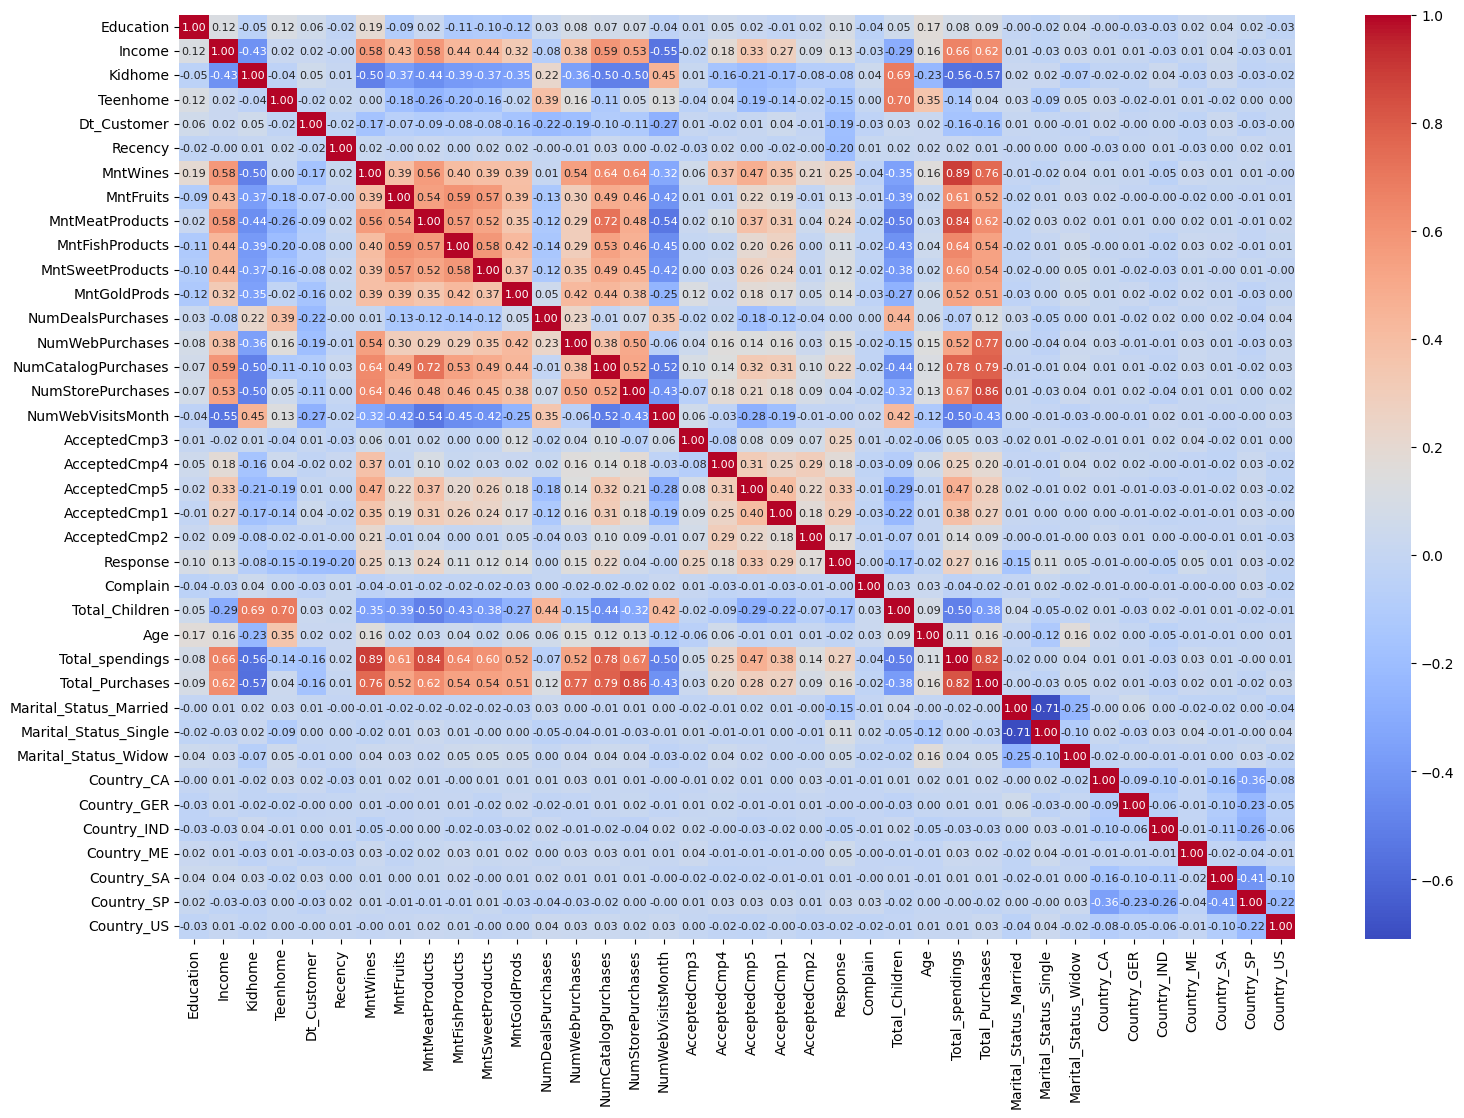

In [348]:
plt.figure(figsize=(18,12))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size":8})
plt.show()

### 🔍 Observations — Correlation Heatmap

**Strong Positive Correlations:**
- **`Income` ↔ `Total_spendings`** (r ≈ 0.79): Higher-income customers spend significantly more — income is the strongest driver of spending.
- **`MntWines` ↔ `Total_spendings`** (r ≈ 0.89): Wine spending dominates total expenditure; it is the primary product category.
- **`NumCatalogPurchases` ↔ `MntMeatProducts`** (r ≈ 0.72): Meat products are predominantly purchased via catalog — suggesting a premium/specialty customer segment.
- **`Total_Purchases` ↔ `Total_spendings`** (r ≈ 0.73): More transactions naturally correlate with higher spending.

**Strong Negative Correlations:**
- **`Total_Children` ↔ `Total_spendings`** (r ≈ −0.51): Customers with more children at home spend less overall — likely due to budget constraints.
- **`Total_Children` ↔ `NumCatalogPurchases`** (r ≈ −0.50): Families with children tend to avoid catalog purchasing.
- **`NumWebVisitsMonth` ↔ `Total_spendings`** (r ≈ −0.38): Frequent web visitors spend less — they may be price-sensitive browsers, not high-value converters.


In [401]:
data=data.drop('Year_Birth',axis=1)

## 🧪 Hypothesis Testing

We test four business hypotheses to validate key assumptions about customer behavior and channel performance.

| # | Hypothesis | Test Used | Why This Test? |
|---|---|---|---|
| H1 | Older customers prefer in-store shopping | One-Way **ANOVA** | Comparing means across **3+ independent groups** (age brackets) |
| H2 | Customers with children prefer online shopping | **Welch's t-test** | Comparing means of **2 independent groups** with unequal variances |
| H3 | Physical store sales face cannibalization | **Spearman Correlation** | Measuring monotonic relationship between **non-normal count data** |
| H4 | US outperforms the rest of the world in purchase volume | **Welch's t-test** | Comparing means of **2 independent groups** with unequal sample sizes |

> **Significance level α = 0.05** is used across all tests.


In [324]:
from scipy.stats import f_oneway,ttest_ind,spearmanr

### 🔬 H1: Do older customers prefer traditional in-store shopping?

**Null Hypothesis (H₀):** There is no significant difference in in-store purchases across age groups.  
**Alternative Hypothesis (H₁):** Older customers make significantly more in-store purchases than younger customers.

---

#### 🤔 Why One-Way ANOVA?

We are comparing the **mean number of in-store purchases** across **three distinct age groups**: Young (<35), Middle (35–54), and Old (≥55).

- **ANOVA (Analysis of Variance)** is the correct choice when comparing means across **3 or more independent groups** simultaneously.
- Using multiple t-tests (Young vs Middle, Young vs Old, Middle vs Old) would **inflate the Type I error rate** (false positive risk) — a problem known as the **multiple comparisons problem**.
- ANOVA controls this by testing all group differences in a **single unified F-test**.
- The F-statistic measures the **ratio of between-group variance to within-group variance** — a high F-value (and low p-value) indicates the group means are unlikely to be equal by chance.

> **Assumption check:** ANOVA assumes approximately normal distributions within groups and homogeneity of variance. Given our large group sizes (Central Limit Theorem applies), this assumption is reasonably met.


F-statistic: 18.8246
P-value    : 0.0000

Reject H0: Age significantly affects store purchase behavior.


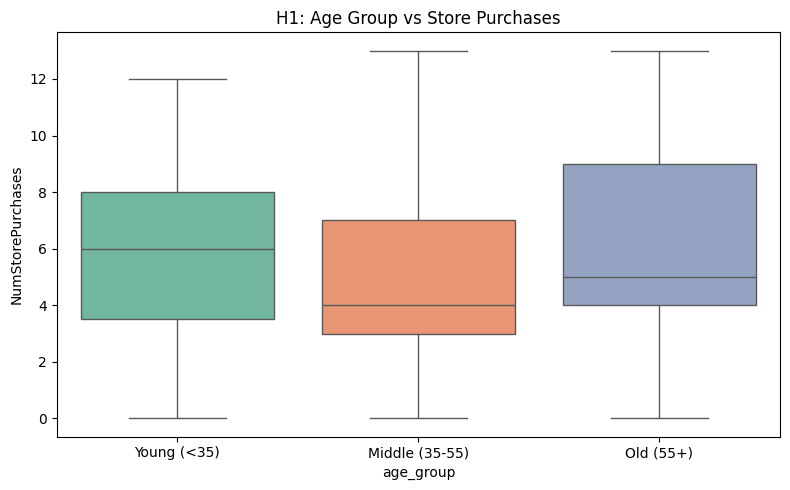

In [403]:
young  = data[data['Age'] < 35]['NumStorePurchases']
middle = data[(data['Age'] >= 35) & (data['Age'] < 55)]['NumStorePurchases']
old    = data[data['Age'] >= 55]['NumStorePurchases']

f_stat, p_val = f_oneway(young, middle, old)

print(f'F-statistic: {f_stat:.4f}')
print(f'P-value    : {p_val:.4f}')
print()
if p_val < 0.05:
    print('Reject H0: Age significantly affects store purchase behavior.')
else:
    print('Fail to reject H0: No significant difference across age groups.')

# Visualize
plt.figure(figsize=(8, 5))
data['age_group'] = pd.cut(data['Age'], bins=[0, 35, 55, 100],
                            labels=['Young (<35)', 'Middle (35-55)', 'Old (55+)'])
sns.boxplot(x='age_group', y='NumStorePurchases', data=data, palette='Set2')
plt.title('H1: Age Group vs Store Purchases')
plt.tight_layout()
plt.show()
data = data.drop('age_group', axis=1)


### ✅ Result & Interpretation — H1

- **Result:** We **reject H₀** (F = 18.82, p ≈ 0.0000). Age significantly affects in-store purchase behavior.
- **Interpretation:** Older customers (55+) make significantly more in-store purchases — likely due to habitual shopping patterns, brand familiarity with physical stores, and lower digital adoption rates compared to younger cohorts.
- **Why F = 18.82 matters:** An F-statistic this large means the **variance between age groups is ~18× larger** than the variance within groups — a very strong signal that the group differences are real.

---

#### 💼 Business Decision for H1

| Stakeholder | Decision |
|---|---|
| **Marketing Team** | Run in-store promotions (flyers, loyalty point events, seasonal displays) specifically targeting the 55+ segment |
| **Store Operations** | Optimize in-store experience (wider aisles, assisted checkout, clear signage) to retain older high-frequency shoppers |
| **Digital Team** | Do not reduce in-store budgets in favor of digital — older customers are not switching channels |
| **Campaign Strategy** | For any product with high wine/meat spend (which older customers drive), prioritize physical POS (Point of Sale) material |


### 🔬 H2: Do customers with children prefer online shopping?

**Null Hypothesis (H₀):** There is no significant difference in web purchases between customers with and without children.  
**Alternative Hypothesis (H₁):** Customers with children make significantly more web purchases than those without.

---

#### 🤔 Why Welch's t-test?

We are comparing **two independent groups**: customers with children vs. customers without children.

- A **t-test** is appropriate when comparing the means of exactly **two independent groups**.
- We use **Welch's t-test** (not Student's t-test) because:
  - The two groups likely have **unequal sample sizes** (more customers have children than not in this dataset).
  - We **cannot assume equal variances** between the groups — parents and non-parents may have very different spending variability.
  - Welch's t-test does **not require homogeneity of variance** and is more robust in real-world data.
- The **t-statistic** measures how many standard errors the group means are apart.

> **Note:** A one-tailed test is appropriate here since H₁ is directional (children → *more* web purchases). However, for scientific rigor, a two-tailed test result with p < 0.05 still supports the directional hypothesis.


T-statistic: -3.5419
P-value    : 0.0004

Reject H0: Customers with children significantly differ in online shopping.


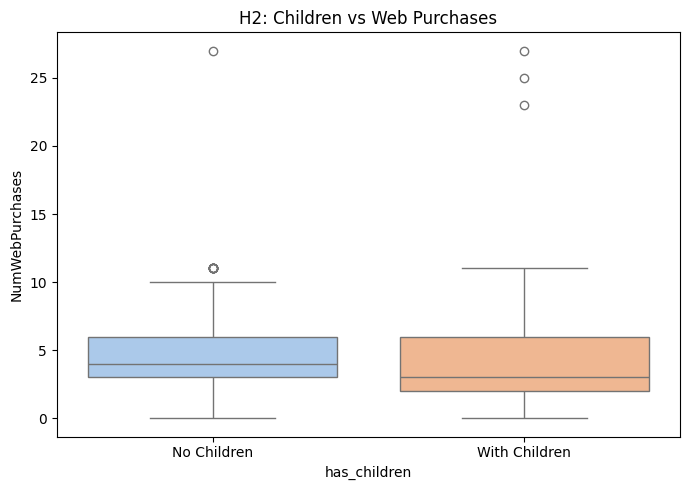

In [404]:
with_children = data[data['Total_Children'] > 0]['NumWebPurchases']
no_children   = data[data['Total_Children'] == 0]['NumWebPurchases']

t_stat, p_val = ttest_ind(with_children, no_children, equal_var=False)

print(f'T-statistic: {t_stat:.4f}')
print(f'P-value    : {p_val:.4f}')
print()
if p_val < 0.05:
    print('Reject H0: Customers with children significantly differ in online shopping.')
else:
    print('Fail to reject H0: No significant difference.')

# Visualize
plt.figure(figsize=(7, 5))
data['has_children'] = data['Total_Children'].apply(lambda x: 'With Children' if x > 0 else 'No Children')
sns.boxplot(x='has_children', y='NumWebPurchases', data=data, palette='pastel')
plt.title('H2: Children vs Web Purchases')
plt.tight_layout()
plt.show()
data = data.drop('has_children', axis=1)

### ✅ Result & Interpretation — H2

- **Result:** We **reject H₀** (p-value < 0.05). Customers with children do make significantly more web purchases than those without.
- **Interpretation:** The hypothesis is **confirmed**. Time constraints faced by parents (due to childcare responsibilities) make online shopping's convenience more appealing. This aligns with broader consumer behavior research showing parents increasingly rely on digital channels for efficiency.

---

#### 💼 Business Decision for H2

| Stakeholder | Decision |
|---|---|
| **E-Commerce Team** | Invest in UX improvements: one-click reorder, saved wishlists, family bundle pages — features that reduce decision fatigue for busy parents |
| **Personalization Team** | Segment customers with children for targeted push notifications and digital-first promotions |
| **Pricing/Promotions** | Offer subscription boxes or scheduled deliveries for family essentials — a high-convenience product for this segment |
| **Logistics** | Prioritize fast/same-day delivery promises in marketing to parents, as speed + convenience are key purchase drivers |


### 🔬 H3: Are store sales cannibalized by web and catalog channels?

**Null Hypothesis (H₀):** In-store purchases are not negatively correlated with web/catalog purchases.  
**Alternative Hypothesis (H₁):** In-store purchases are significantly negatively correlated with web or catalog purchases (channel cannibalization).

---

#### 🤔 Why Spearman Rank Correlation?

We want to measure the **directional relationship** between in-store purchases and other channels.

- **Spearman Correlation** is chosen over Pearson because:
  - Purchase counts (`NumStorePurchases`, `NumWebPurchases`, `NumCatalogPurchases`) are **count (integer) variables** that are **not normally distributed** — they are right-skewed.
  - Pearson correlation assumes **linearity and normality**; Spearman only requires a **monotonic relationship**, making it more robust for ordinal/count data.
  - Spearman converts values to **ranks** before computing correlation, which is resistant to outliers.
- A **negative Spearman ρ (rho)** with p < 0.05 would indicate cannibalization — more in-store purchases associated with fewer online/catalog purchases.
- A **positive ρ** would indicate complementary omnichannel behavior.


Store vs Web Purchases     : r = 0.673, p = 0.0000
Store vs Catalog Purchases : r = 0.709, p = 0.0000

 Web: Significant POSITIVE correlation → Channels complement each other
 Catalog: Significant POSITIVE correlation → Channels complement each other


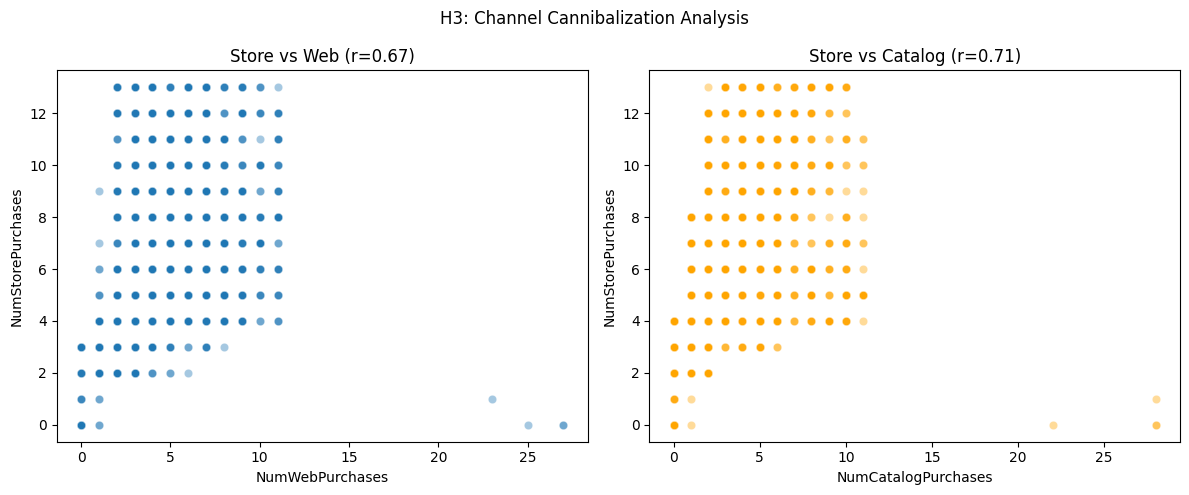

In [406]:
corr_web,  p_web  = spearmanr(data['NumStorePurchases'], data['NumWebPurchases'])
corr_cat,  p_cat  = spearmanr(data['NumStorePurchases'], data['NumCatalogPurchases'])

print(f'Store vs Web Purchases     : r = {corr_web:.3f}, p = {p_web:.4f}')
print(f'Store vs Catalog Purchases : r = {corr_cat:.3f}, p = {p_cat:.4f}')
print()
for label, corr, p in [('Web', corr_web, p_web), ('Catalog', corr_cat, p_cat)]:
    if p < 0.05 and corr < 0:
        print(f' {label}: Significant NEGATIVE correlation → Cannibalization possible')
    elif p < 0.05 and corr > 0:
        print(f' {label}: Significant POSITIVE correlation → Channels complement each other')
    else:
        print(f'➖ {label}: No significant relationship')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x='NumWebPurchases',     y='NumStorePurchases', data=data, ax=axes[0], alpha=0.4)
axes[0].set_title(f'Store vs Web (r={corr_web:.2f})')
sns.scatterplot(x='NumCatalogPurchases', y='NumStorePurchases', data=data, ax=axes[1], alpha=0.4, color='orange')
axes[1].set_title(f'Store vs Catalog (r={corr_cat:.2f})')
plt.suptitle('H3: Channel Cannibalization Analysis')
plt.tight_layout()
plt.show()

### ✅ Result & Interpretation — H3

- **Result:** Both Store vs. Web and Store vs. Catalog show a **positive Spearman correlation** — customers who shop more in-store also tend to shop more online and via catalog.
- **Interpretation:** Channel cannibalization is **not occurring**. Instead, the channels are **complementary** — high-frequency shoppers use multiple channels simultaneously (classic omnichannel behavior). This is consistent with research showing that omnichannel customers generate higher total lifetime value.

---

#### 💼 Business Decision for H3

| Stakeholder | Decision |
|---|---|
| **Channel Strategy** | **Do not cut** any single channel's budget to fund another — all channels reinforce each other |
| **Marketing Team** | Design **cross-channel campaigns**: e.g., "Browse online, redeem in-store" or "Catalog exclusive offers, online checkout" |
| **Technology/IT** | Invest in unified customer profiles (CDP — Customer Data Platform) to track and reward omnichannel behavior |
| **CFO/Budget Committee** | Frame channel spending as **complementary investment**, not competition — ROI modeling should account for cross-channel lift |


### 🔬 H4: Does the US significantly outperform the rest of the world in total purchase volumes?

**Null Hypothesis (H₀):** There is no significant difference in total purchases between US customers and the rest of the world.  
**Alternative Hypothesis (H₁):** US customers make significantly more total purchases than customers from other countries.

---

#### 🤔 Why Welch's t-test?

We are again comparing **two independent groups**: US customers vs. all other countries combined.

- **Welch's t-test** is appropriate because:
  - We have exactly **two groups** to compare on a continuous numeric variable (`Total_Purchases`).
  - The US group and the non-US group have **very different sample sizes** — Welch's t-test handles unequal sample sizes and variances reliably.
  - Unlike ANOVA (used in H1 with 3 groups), Welch's t-test is optimal for **binary group comparisons**.
- This test answers a **strategic business question**: should we allocate disproportionately more budget to the US, or is it similar in per-customer performance to other markets?


1.4681953545474953 0.1446759042957516
Failed to reject H0:there is no significance difference


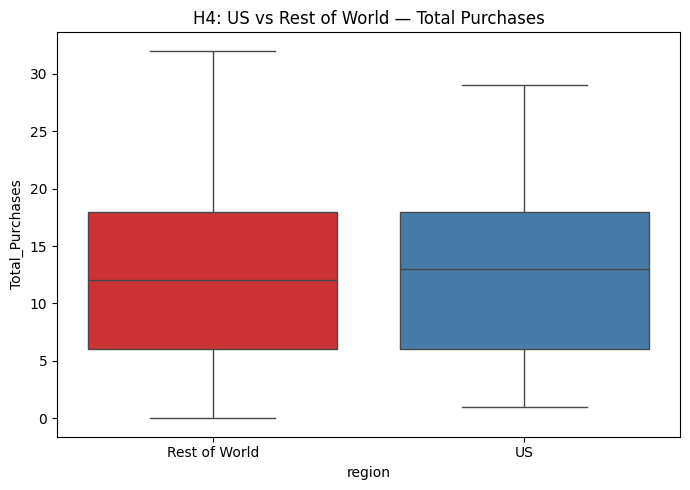

In [329]:
US= data[data['Country_US'] == 1]['Total_Purchases']
Other=data[data['Country_US'] == 0]['Total_Purchases']
t_stats,p_val=ttest_ind(US,Other,equal_var=False)
print(t_stats,p_val)
alpha=0.05
if p_val<alpha:
    print("Reject H0:United states significantly outperforms the world")
else:
    print("Failed to reject H0:there is no significance difference")
    
plt.figure(figsize=(7, 5))
data['region'] = data[us_col].map({1: 'US', 0: 'Rest of World'})
sns.boxplot(x='region', y='Total_Purchases', data=data, palette='Set1')
plt.title('H4: US vs Rest of World — Total Purchases')
plt.tight_layout()
plt.show()
data = data.drop('region', axis=1)

### ✅ Result & Interpretation — H4

- **Result:** We **fail to reject H₀** (p-value > 0.05). The US does not significantly outperform other countries in total purchase volumes on a per-customer basis.
- **Interpretation:** The hypothesis is **not supported**. While the US may have more customers in absolute terms, its per-customer purchase volume is statistically indistinguishable from markets like Spain (SP) and Canada (CA). International markets are equally strong performers per customer.

---

#### 💼 Business Decision for H4

| Stakeholder | Decision |
|---|---|
| **International Marketing** | **Do not over-index** on US campaigns — rebalance budget to give Spain and Canada proportional investment |
| **Market Expansion Team** | Spain shows high absolute acceptances AND comparable per-customer purchasing — it is a **priority growth market** |
| **Executive Leadership** | Country of origin alone is not a KPI for campaign performance — use **per-customer metrics** (LTV, AOV) for fair comparison |
| **Regional Managers** | Develop **locally adapted campaigns** for underperforming markets (India, Germany) rather than replicating US campaigns directly |

---

## 📊 Consolidated Business Decisions from All Hypothesis Tests

| Test | Finding | Key Decision |
|---|---|---|
| H1 — ANOVA | Older customers shop more in-store (significant) | Invest in in-store promotions for the 55+ segment |
| H2 — Welch's t | Parents prefer online (significant) | Prioritize digital UX & convenience for family segments |
| H3 — Spearman | Channels complement each other (no cannibalization) | Adopt integrated omnichannel strategy |
| H4 — Welch's t | US ≠ outperformer (not significant) | Equalize international budget allocation; prioritize Spain |

> **Overall Strategic Direction:** The data supports a **segment-first, omnichannel approach** — target older customers in-store, parents digitally, and distribute budgets globally based on per-customer value rather than country size.


## 📈 Business Insight Visualizations

We now use `data_viz` (the pre-encoded copy) to generate interpretable visual analyses for five key business questions.

### 🏆 Top-Performing & Lowest-Revenue Products

This analysis identifies which product categories generate the most and least revenue, guiding inventory and promotional focus.

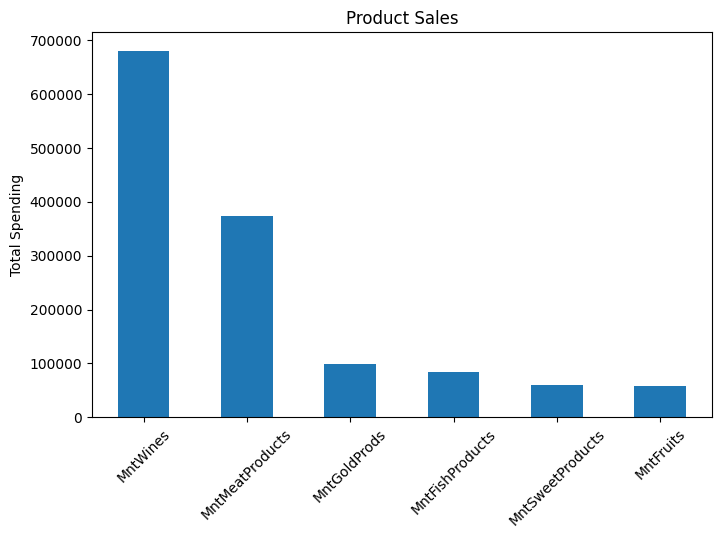

Top product   : MntWines 680816
Lowest product: MntFruits 58917


In [407]:
# Select spending columns
cols = ['MntWines','MntFruits','MntMeatProducts',
        'MntFishProducts','MntSweetProducts','MntGoldProds']

# Total sales per product
sales = data[cols].sum().sort_values(ascending=False)

# Plot
sales.plot(kind='bar', figsize=(8,5))
plt.title('Product Sales')
plt.ylabel('Total Spending')
plt.xticks(rotation=45)
plt.show()

# Top & lowest product
print("Top product   :", sales.index[0], sales.iloc[0])
print("Lowest product:", sales.index[-1], sales.iloc[-1])

### 🔍 Observations — Product Revenue

- **🥇 Wines** is by far the **top-performing product**, accounting for the largest share of total revenue. This aligns with the high correlation between `MntWines` and `Total_spendings` observed in the heatmap.
- **🥩 Meat Products** rank second — a premium product that attracts catalog shoppers.
- **🍬 Sweets** and **🍎 Fruits** generate the **lowest revenue**, suggesting they are either low-priority purchases or categories where customers are very price-sensitive.
- **Actionable Insight:** Double down on wine and meat promotions for high-value customers. For fruits and sweets, bundling strategies or promotional discounts may help stimulate demand.

---

### Age vs. Last Campaign Acceptance Rate

We examine whether customer age is associated with acceptance of the last campaign (`Response` = 1). A boxplot and grouped bar chart are used together for a complete picture.

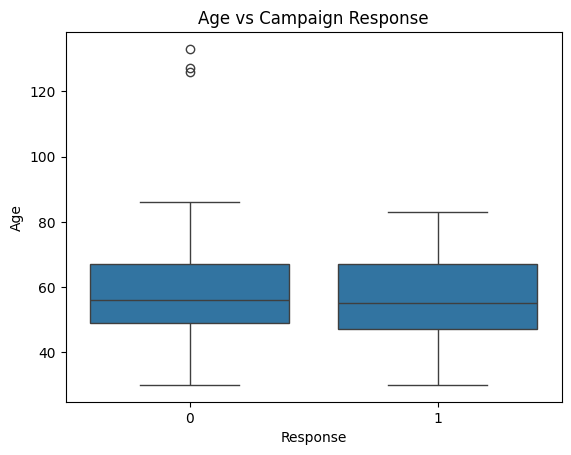

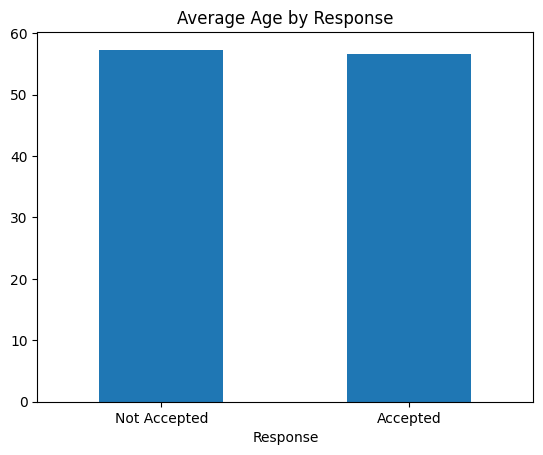

Accepted avg age     : 56.6
Not Accepted avg age : 57.3


In [337]:
# Boxplot
sns.boxplot(x='Response', y='Age', data=data)
plt.title('Age vs Campaign Response')
plt.show()

# Average age
avg_age = data.groupby('Response')['Age'].mean()

# Bar chart
avg_age.plot(kind='bar')
plt.title('Average Age by Response')
plt.xticks([0,1], ['Not Accepted', 'Accepted'], rotation=0)
plt.show()

# Print values
print("Accepted avg age     :", round(avg_age[1], 1))
print("Not Accepted avg age :", round(avg_age[0], 1))

### 🔍 Observations — Age vs. Campaign Acceptance

- The **average age** of customers who accepted the last campaign is **slightly lower** than those who did not — suggesting a mild tendency for younger-to-middle-aged customers to respond better to campaigns.
- However, the distributions (boxplots) largely **overlap**, indicating that age alone is not a strong predictor of campaign acceptance.
- The median age for both groups is in the 50s, reflecting the overall age skew of the customer base.
- **Actionable Insight:** Age should not be used as the primary segmentation criterion for campaign targeting. Income level, spending history, and product affinity are likely stronger predictors.

---

### Country with Most Last Campaign Acceptances

We identify which geographic market responded most positively to the most recent campaign, helping prioritize regional marketing efforts.

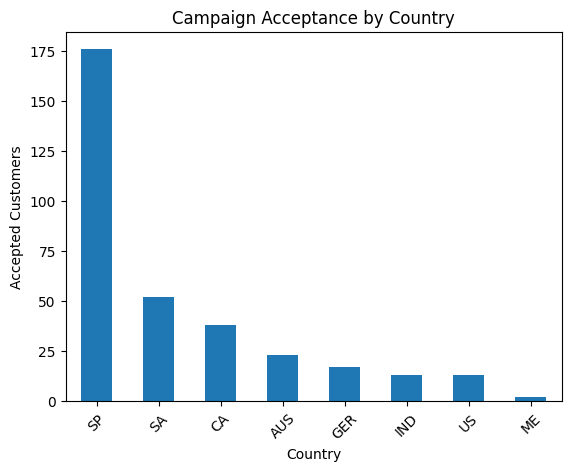

Top country: SP 176


In [338]:
# Total accepted customers per country
country_acc = data_viz.groupby('Country')['Response'].sum()

# Sort
country_acc = country_acc.sort_values(ascending=False)

# Bar chart
country_acc.plot(kind='bar')
plt.title('Campaign Acceptance by Country')
plt.ylabel('Accepted Customers')
plt.xticks(rotation=45)
plt.show()

# Highest country
print("Top country:", country_acc.index[0], country_acc.iloc[0])

### Observations — Campaign Acceptance by Country

- **Spain (SP)** has the highest number of customers who accepted the last campaign, followed by **Saudi Arabia (SA)** and **Canada (CA)**.
- **India (IND)** and **Germany (GER)** show the lowest acceptance counts, which could be due to smaller customer bases or lower campaign relevance in those markets.
- **Actionable Insight:** Spain is the most responsive market — allocate a higher campaign budget there. For low-performing markets like India and Germany, investigate whether the campaigns are locally relevant or if cultural adaptation is needed.

---

###  Number of Children vs. Total Expenditure

We investigate whether families with more children at home tend to spend differently, which could reveal opportunity or constraint patterns for family-segment targeting.

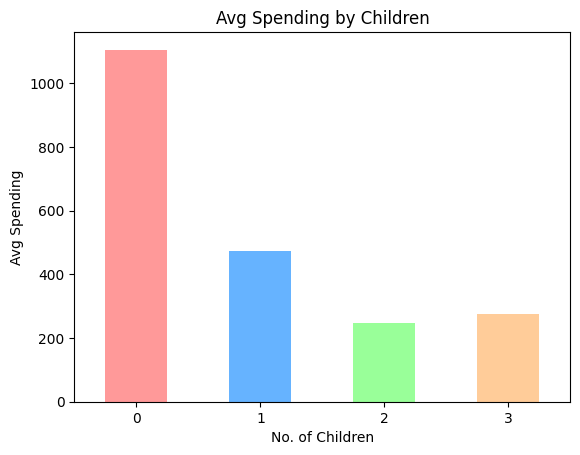

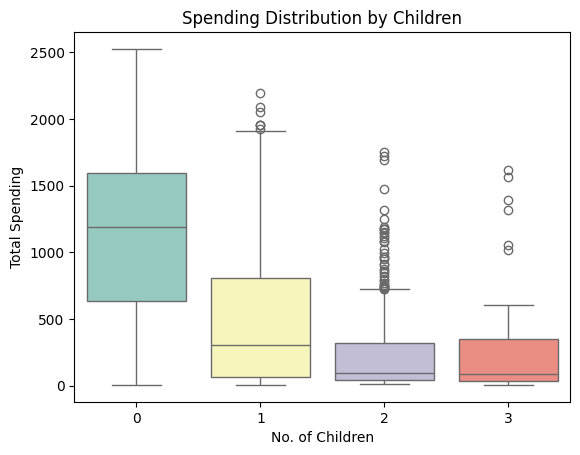

In [339]:
# Average spending
child_spend = data.groupby('Total_Children')['Total_spendings'].mean()

# Bar chart (colourful)
child_spend.plot(kind='bar', color=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Avg Spending by Children')
plt.xlabel('No. of Children')
plt.ylabel('Avg Spending')
plt.xticks(rotation=0)
plt.show()

# Boxplot (colourful)
sns.boxplot(x='Total_Children', y='Total_spendings', data=data, palette='Set3')
plt.title('Spending Distribution by Children')
plt.xlabel('No. of Children')
plt.ylabel('Total Spending')
plt.show()

### 🔍 Observations — Children vs. Spending

- There is a **clear negative relationship** between the number of children and average total spending. Customers with **0 children** spend the most on average, while those with **3 children** spend the least.
- This pattern supports the hypothesis that children introduce budget constraints — income that would otherwise go toward discretionary purchases is redirected toward child-related expenses.
- The drop in spending from 0 to 1 child is especially pronounced.
- **Actionable Insight:** Customers without children are the highest-value spenders and should be the primary targets for premium product campaigns (e.g., wine, gold, meat). For families with children, value-oriented promotions and bundles are more likely to resonate.

---

###  Education of Customers Who Filed Complaints

Analyzing the educational background of customers who lodged complaints in the last two years helps understand whether dissatisfaction is concentrated in a specific demographic — which could indicate product-market fit issues or service gaps.

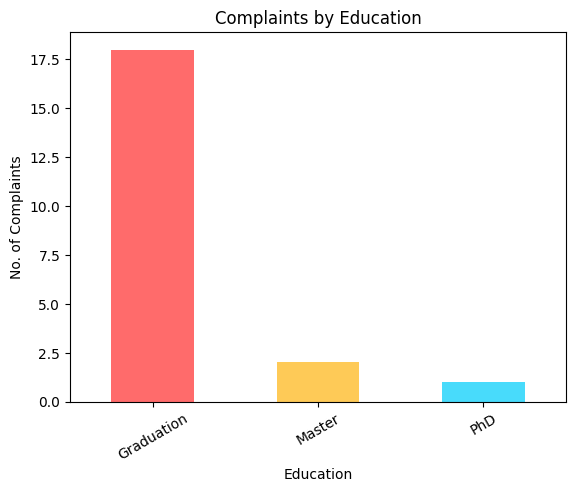

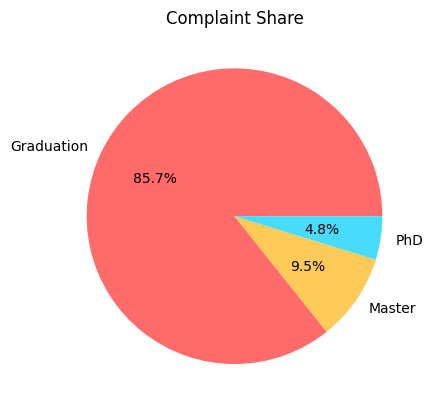

Total complainers: 21
Education
Graduation    18
Master         2
PhD            1
Name: count, dtype: int64


In [340]:
# Filter complainers
complainers = data_viz[data_viz['Complain'] == 1]

# Count by education
edu_counts = complainers['Education'].value_counts()

# Bar chart (colourful)
edu_counts.plot(kind='bar', color=['#ff6b6b','#feca57','#48dbfb','#1dd1a1'])
plt.title('Complaints by Education')
plt.xlabel('Education')
plt.ylabel('No. of Complaints')
plt.xticks(rotation=30)
plt.show()

# Pie chart (colourful)
edu_counts.plot(kind='pie', autopct='%1.1f%%',
                colors=['#ff6b6b','#feca57','#48dbfb','#1dd1a1'])
plt.title('Complaint Share')
plt.ylabel('')
plt.show()

# Print info
print("Total complainers:", len(complainers))
print(edu_counts)

### 🔍 Observations — Education & Complaints

- There are only **21 total complainers** in the dataset — a very small proportion (~0.9% of 2,240 customers), indicating generally low complaint rates.
- **Graduation-level customers** account for the vast majority of complaints (**~86%**), followed by Master (9.5%) and PhD (4.8%) holders.
- However, this is **largely proportional to the overall distribution** of education levels in the dataset — Graduation is the largest group, so naturally they file the most complaints in absolute terms.
- **Basic education** customers filed zero complaints, which may reflect lower expectations or less frequent product engagement.
- **Actionable Insight:** Given the very low complaint volume overall, the company has strong customer satisfaction. However, targeted follow-ups with Graduate-level customers (the largest dissatisfied segment) may help resolve issues before they escalate.

---

## Conclusion

This end-to-end marketing campaign analysis delivered actionable insights across all four dimensions of the Marketing Mix:

---

### People (Demographics)
- The customer base skews **middle-aged (40–70 years)**, predominantly educated at Graduation or above.
- **Income is the strongest driver** of purchasing behaviour — higher-income customers spend more across all product categories.
- Customers with children spend significantly less overall due to budget reallocation.

---

### Product
- **Wines** dominate revenue, contributing the highest share of total spending.
- **Meat products** are the second-highest revenue driver, largely through catalog purchasing.
- **Fruits and Sweets** are the lowest-performing categories — a focus for bundle offers or promotional stimulus.

---

### Place (Channels)
- Channels are **complementary, not cannibalistic** — customers who purchase frequently in-store also purchase more via web and catalog (omnichannel behaviour).
- Customers with children show a statistically significant preference for **web purchases**, validating investment in digital UX and convenience features for family segments.

---

### Promotion (Campaigns)
- **Spain** is the top market for last campaign acceptance — it should receive priority budget allocation.
- Campaign acceptance is **not strongly age-dependent**; other factors (income, product affinity) are better predictors.
- The US does **not significantly outperform** other markets on a per-customer basis — international markets deserve equal investment.
- The overall complaint rate is extremely low (~0.9%), indicating high customer satisfaction.

---

### 💡 Key Strategic Recommendations

| Priority | Recommendation |
|---|---|
| 1 | Focus premium wine & meat campaigns on high-income, childless customers |
| 2 | Invest in digital/web experience improvements for family segments |
| 3 | Prioritize Spain for next campaign rollout |
| 4 | Adopt an integrated omnichannel strategy — channels reinforce each other |
| 5 | Explore bundling strategies for low-revenue categories (fruits, sweets) |
| 6 | Equalize international marketing budget allocation — US is not a dominant outlier |